## 2 — GLM-MRP
Frequentist logistic regression with **all fixed effects** + MRP poststratification.

Model formula (no random effects):
```
happening_bin ~ C(gender) + C(race4) + C(educ_category)
              + co2_per_capita + dem_share_two_party
              + pct_drive_alone + pct_samesex_hh
```
`region9` / `division` are **not** predictors here — they only appear in hierarchical models
(GLMER-MRP, GLMERStan) as the hyperprior that partially pools state intercepts.  
State-level variation enters GLM-MRP solely through the four continuous covariates.

Output: `outputs/estimates/glm_mrp_state_estimates.csv`

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

DATA_DIR   = Path("../test_data/processed/")
RAW_DIR    = Path("../test_data/raw/")
OUTPUT_DIR = Path("../outputs/")
OUTCOME    = "happening_bin"
MODEL_NAME = "glm_mrp"

FORMULA = (
    "happening_bin ~ C(gender) + C(race4) + C(educ_category)"
    " + co2_per_capita + dem_share_two_party + pct_drive_alone + pct_samesex_hh"
)

STATE_NAMES = {
    "01":"Alabama","02":"Alaska","04":"Arizona","05":"Arkansas","06":"California",
    "08":"Colorado","09":"Connecticut","10":"Delaware","11":"District of Columbia",
    "12":"Florida","13":"Georgia","15":"Hawaii","16":"Idaho","17":"Illinois",
    "18":"Indiana","19":"Iowa","20":"Kansas","21":"Kentucky","22":"Louisiana",
    "23":"Maine","24":"Maryland","25":"Massachusetts","26":"Michigan",
    "27":"Minnesota","28":"Mississippi","29":"Missouri","30":"Montana",
    "31":"Nebraska","32":"Nevada","33":"New Hampshire","34":"New Jersey",
    "35":"New Mexico","36":"New York","37":"North Carolina","38":"North Dakota",
    "39":"Ohio","40":"Oklahoma","41":"Oregon","42":"Pennsylvania",
    "44":"Rhode Island","45":"South Carolina","46":"South Dakota",
    "47":"Tennessee","48":"Texas","49":"Utah","50":"Vermont",
    "51":"Virginia","53":"Washington","54":"West Virginia","55":"Wisconsin",
    "56":"Wyoming",
}

In [2]:
# ── State-level covariates ────────────────────────────────────────────────────
carbon  = pd.read_csv(RAW_DIR / "carbon_state.csv",  dtype={"state_fips": str})[["state_fips","co2_per_capita"]]
pres    = pd.read_csv(RAW_DIR / "pres_state.csv",    dtype={"state_fips": str})[["state_fips","dem_share_two_party"]]
acs_ext = pd.read_csv(DATA_DIR / "acs_state_extra_covariates.csv", dtype={"state_fips": str})

state_cov = carbon.merge(pres, on="state_fips").merge(acs_ext, on="state_fips")

# ── Load survey + merge state covariates ──────────────────────────────────────
survey = pd.read_csv(DATA_DIR / "climate_survey_responses_recoded.csv", dtype={"state_fips": str})
survey = survey.dropna(subset=[OUTCOME]).copy()
survey[OUTCOME] = survey[OUTCOME].astype(float)
survey["educ_category"] = survey["educ_category"].astype(str)
survey = survey.merge(state_cov, on="state_fips", how="left")

print(f"Survey rows: {len(survey):,}  ({survey[OUTCOME].mean()*100:.1f}% Yes)")
print(f"Missing co2: {survey['co2_per_capita'].isna().sum()}")

Survey rows: 1,010  (68.1% Yes)
Missing co2: 0


In [3]:
# ── Load poststrat frame + merge state covariates ─────────────────────────────
ps_raw = pd.read_csv(DATA_DIR / "poststrat_state.csv", dtype={"state_fips": str})
ps = ps_raw[["state_fips","gender","race4","educ_category","N_rounded"]].copy()
ps["educ_category"] = ps["educ_category"].astype(str)
ps = ps.merge(state_cov, on="state_fips", how="left")

print(f"Poststrat rows: {len(ps):,}  |  states: {ps['state_fips'].nunique()}")
print(ps.head(4).to_string(index=False))

Poststrat rows: 1,632  |  states: 51
state_fips gender race4 educ_category  N_rounded  co2_per_capita  dem_share_two_party  pct_drive_alone  pct_samesex_hh
        01 Female Black             1      61051       25.262407             0.345594         0.814562        0.005769
        01 Female Black             2     171337       25.262407             0.345594         0.814562        0.005769
        01 Female Black             3     196091       25.262407             0.345594         0.814562        0.005769
        01 Female Black             4     116020       25.262407             0.345594         0.814562        0.005769


In [4]:
# ── Fit GLM ───────────────────────────────────────────────────────────────────
caught = []
with warnings.catch_warnings(record=True) as _w:
    warnings.simplefilter("always")
    model = smf.glm(
        formula=FORMULA, data=survey,
        family=sm.families.Binomial(link=sm.families.links.Logit()),
    ).fit()
    caught = list(_w)

pseudo_r2 = 1 - model.llf / model.llnull
print(f"AIC: {model.aic:.1f}  |  Pseudo R² (McFadden): {pseudo_r2:.4f}")
print(f"Convergence warnings: {len(caught)}")
print(model.summary().tables[1])

AIC: 1261.4  |  Pseudo R² (McFadden): 0.0214
Convergence warnings: 0
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.3106      1.505     -0.206      0.836      -3.260       2.639
C(gender)[T.Male]        -0.1759      0.138     -1.276      0.202      -0.446       0.094
C(race4)[T.Hispanic]     -0.0573      0.269     -0.213      0.831      -0.584       0.469
C(race4)[T.Other]         0.3009      0.353      0.853      0.394      -0.391       0.993
C(race4)[T.White]         0.0861      0.234      0.368      0.713      -0.373       0.545
C(educ_category)[T.2]    -0.1449      0.228     -0.635      0.525      -0.592       0.302
C(educ_category)[T.3]     0.0966      0.226      0.426      0.670      -0.347       0.541
C(educ_category)[T.4]     0.3647      0.235      1.553      0.120      -0.096       0.825
co2_per_capita           -0.015

In [5]:
# ── Predict + poststratify ────────────────────────────────────────────────────
ps["predicted_prob"] = model.predict(ps)

estimates = (
    ps.groupby("state_fips")
    .apply(lambda g: np.average(g["predicted_prob"], weights=g["N_rounded"]),
           include_groups=False)
    .reset_index(name="estimate")
)
estimates["state_name"] = estimates["state_fips"].map(STATE_NAMES)
n_resp = survey.groupby("state_fips")[OUTCOME].count().reset_index(name="n_respondents")
estimates = estimates.merge(n_resp, on="state_fips", how="left")
estimates["n_respondents"] = estimates["n_respondents"].fillna(0).astype(int)
estimates = estimates.sort_values("estimate", ascending=False).reset_index(drop=True)

print(f"National mean: {estimates['estimate'].mean():.4f}")
print("\nTop 5:"); print(estimates.head(5).to_string(index=False))
print("\nBottom 5:"); print(estimates.tail(5).to_string(index=False))

National mean: 0.6681

Top 5:
state_fips  estimate           state_name  n_respondents
        11  0.845702 District of Columbia              6
        15  0.782759               Hawaii              9
        50  0.776149              Vermont              3
        24  0.771589             Maryland             19
        25  0.768360        Massachusetts             22

Bottom 5:
state_fips  estimate    state_name  n_respondents
        02  0.593960        Alaska              4
        22  0.532603     Louisiana             17
        54  0.505315 West Virginia              7
        38  0.393213  North Dakota              6
        56  0.300807       Wyoming              4


In [6]:
est_dir  = OUTPUT_DIR / "estimates"
diag_dir = OUTPUT_DIR / "diagnostics"
est_dir.mkdir(parents=True, exist_ok=True)
diag_dir.mkdir(parents=True, exist_ok=True)

out_path = est_dir / f"{MODEL_NAME}_state_estimates.csv"
estimates.to_csv(out_path, index=False)
print(f"Saved → {out_path}")

diag_path = diag_dir / f"{MODEL_NAME}_summary.txt"
valid = estimates.dropna(subset=["estimate"])
with open(diag_path, "w") as f:
    f.write("GLM-MRP — Diagnostic Summary\n" + "=" * 55 + "\n\n")
    f.write(f"Formula: {FORMULA}\n")
    f.write(f"Observations: {int(model.nobs)}\n")
    f.write(f"AIC: {model.aic:.2f}\n")
    f.write(f"Pseudo R² (McFadden): {pseudo_r2:.4f}\n\n")
    if caught:
        f.write("Convergence warnings:\n")
        for w in caught: f.write(f"  {w.category.__name__}: {w.message}\n")
    else:
        f.write("Convergence warnings: none\n")
    f.write("\n" + str(model.summary()) + "\n\n")
    f.write(f"State estimates — mean:{valid['estimate'].mean():.4f}  ")
    f.write(f"min:{valid['estimate'].min():.4f}  max:{valid['estimate'].max():.4f}\n")
print(f"Diagnostics → {diag_path}")

Saved → ../outputs/estimates/glm_mrp_state_estimates.csv
Diagnostics → ../outputs/diagnostics/glm_mrp_summary.txt


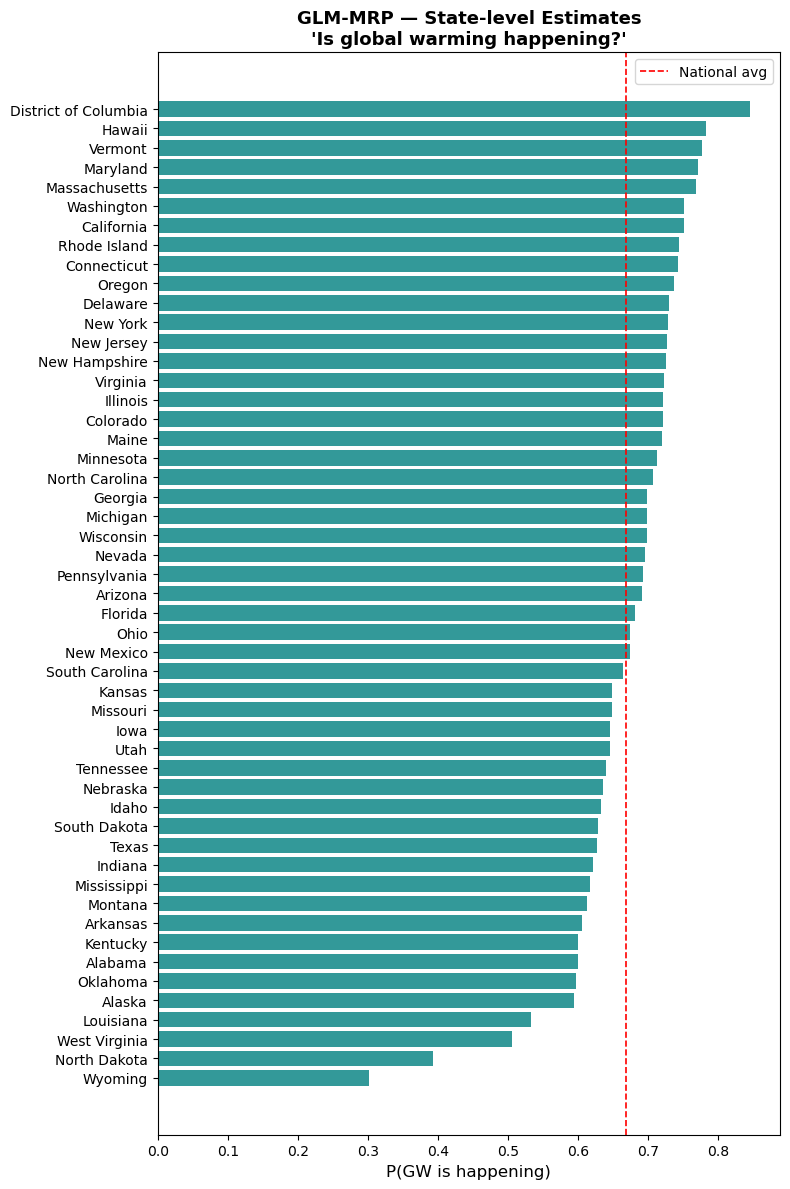

In [7]:
fig, ax = plt.subplots(figsize=(8, 12))
plot_df = estimates.sort_values("estimate")
ax.barh(plot_df["state_name"], plot_df["estimate"], color="teal", alpha=0.8)
ax.axvline(estimates["estimate"].mean(), color="red", linestyle="--", linewidth=1.2, label="National avg")
ax.set_xlabel("P(GW is happening)", fontsize=12)
ax.set_title("GLM-MRP — State-level Estimates\n'Is global warming happening?'", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(est_dir / f"{MODEL_NAME}_state_estimates.png", dpi=150, bbox_inches="tight")
plt.show()